# Convolutional Neural Networks (CNN) and Deep Architectures

In these practicals, we will create a first convolutional neural network (CNN). This type of networks mostly rely on alternating layers of convolution and pooling. A convolution layer is a signal processing inspired layer that performs a bunch of convolutions on the layer input and yields filtered outputs known as feature maps. A pooling layer is a sort of subsampling layer. Most of the time, after several Conv/Pool layer pairs, an MLP is plugged to obtain class membership probabilities. When the number of layers is rather high (unclear how high this is), we obtain a deep network.

We will use `PyTorch` as programming framework and build a CNN to solve an image classification task.
 

## Starting with PyTorch

`PyTorch` is an open source library designed to create and train deep nets. It relies on an underlying computation graph. Each node of this graph performs an operation on an input tensor. The possible number of ops is very large (ranging from addition, dot product and more complex non-linear operations). The input tensor of the network will flow through these nodes. 

Here is an example of computation graph:

<img src="graph.png" alt="drawing" width="200"/>

This graph is a tree whose final node output correponds to the following function :

$$f\left( x,y\right) = x^2 + 2y,$$

for some $x$ and $y$. 
To implement this tree in `PyTorch`, each node will be an instance of the `Tensor` class. 
Let us start with the inputs of function $f$ and suppose, we are interested in evaluation function $f$ for the following three pairs $(x,y)$:
* $(x,y) = (1,2)$
* $(x,y) = (2,3)$
* $(x,y) = (3,4)$

Starting with $x$, we shall define a tensor containing the successive values of this input : 
```python
x = torch.tensor([1,2,3],dtype=torch.int8)
print(x,type(x),x.shape,x.dtype)
```
The console answers that `x` is a `tensor([1, 2, 3], dtype=torch.int8)` has type `<class 'torch.Tensor'>`, a shape of `(3)` and a d(ata)type `torch.int8`.

Now we do the same with $y$:
```python
y = torch.tensor([2,3,4])
```
We don't have to define a python variable for each node of the computation graph. We can now ask `pytorch` to build the whole graph by typing:

```python
f = x*x + 2*y
print(f,f.shape,f.dtype)
```
The console answers: `tensor([ 5, 10, 17]) torch.Size([3]) torch.int64`. 
Observe that `f` is a tensor that contains the three desired evaluations of function $f$. If one is only interested in observing the array of values contained in `f`, one can ask for the corresponding `numpy` array:

```python
print(f.numpy())
```

Here is a cell containing the above instructions.

In [1]:
# !pip install -r requirements.txt

In [2]:
import torch

In [3]:
x = torch.tensor([1, 2, 3], dtype=torch.int8)
print("x:", x, type(x), x.shape)
y = torch.tensor([2, 3, 4])
print("y:", y, type(y), y.dtype)
f = x * x + 2 * y
print("f:", f, f.shape, f.dtype)
print("f.numpy():", f.numpy(), type(f.numpy()), f.numpy().dtype)

x: tensor([1, 2, 3], dtype=torch.int8) <class 'torch.Tensor'> torch.Size([3])
y: tensor([2, 3, 4]) <class 'torch.Tensor'> torch.int64
f: tensor([ 5, 10, 17]) torch.Size([3]) torch.int64
f.numpy(): [ 5 10 17] <class 'numpy.ndarray'> int64


## Baseline CNN

We are now almost ready to start building a `pytorch` graph containing convolution or pooling layers instead of the basic operations involved in function $f$. 
But first things first ! We need a dataset to work with and to load in Jupyter. We will be working with the `MNIST` dataset. This dataset contains 28x28 grayscale images of handwritten figures. It has the advantage to be larger than traditional datasets utilized in practicals while it can still hold in memory and converge in a few minutes. Larger or more complicated datasets (more variability in images) would require too many computational efforts.

Execute the following cell to load `MNIST`

**Note** If you plan on using a CUDA GPU environment for the practical, you should by attention to convert your tensors to CUDA format using `.cuda()` and writing `x=x.cuda()`

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [5]:
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

Image shape: torch.Size([1, 28, 28])
Target value: 5
Batched x_train0 shape: torch.Size([1, 1, 28, 28])
Batched y_train0 shape: torch.Size([1, 1])


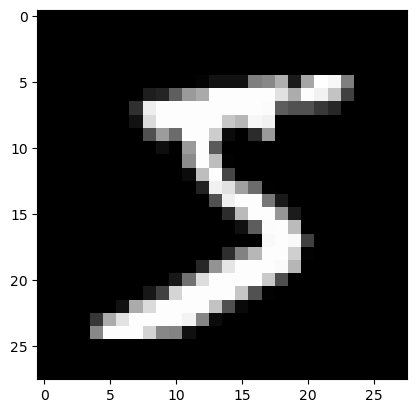

In [6]:
x_train0, y_train0 = train_dataset[0]

print("Image shape:", x_train0.shape)  # images are stored as 3D data, where the first axis corresponds to the number of channels
plt.imshow(x_train0.reshape(28, 28, 1), cmap='gray', interpolation="nearest")  # plt.imshow require channels last, so we need to reshape
print("Target value:", y_train0)

x_train0 = x_train0.reshape(1, 1, 28, 28)  # we reshape the sample, as if it was a part of a batch of size 1
print("Batched x_train0 shape:", x_train0.shape)  # from now on, the first axes corresponds to the index of the sample in the batch

y_train0 = torch.tensor(y_train0, dtype=torch.int32).reshape(1, 1)  # we do the same for y_train0 and we insist on the fact that the label is an integer
print("Batched y_train0 shape:", y_train0.shape)

Let us define some constants that we be useful in the sequel

In [7]:
n = len(train_dataset)
d_x = x_train0.shape[1]
print(n, d_x)

60000 1


We can now begin to build the CNN. Following the explanations in the preamble, it seems like we need to turn the arrays of the dataset into `Tensor` instances. That won't be explicitely necessary because `PyTorch` will do that on its own. So we can readily define a first convoluational layer that we will connect to the batches array `x_train`. 

A second point to mention is that we will use high level functions in this practical session, i.e. functions that in reality translate in multiple nodes of the graph. These classes and functions are accessible through `torch.nn` and `torch.nn.Functional`, respectively. We will see that building a model follows the same philosophy of piling up operations.

One can define individual layers that are then aggregated together in order to construct the end to end model.

The usual layers (with default parameters) that are used in basic CNN architectures are : 
- convolutional layers : `torch.nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=1, padding=0, stride=1, bias=True)`
- activation functions : `torch.nn.Relu`, `torch.nn.Sigmoid`, `torch.nn.SofMax(dim)`
- pooling layers : `torch.nn.MaxPool2d(kernel_size=kernel_size, stride=kernel_size, padding=0)`, `torch.nn.AdaptativeMaxPool2d(output_size)` (or the corresponding `AvgPool2d`, `AdaptativeAvgPool2d` layers)
- flatting layers : `torch.nn.Flatten`
- the glue : `torch.nn.Sequential`


Start by creating one convolution layer (`conv1=torch.nn.Conv2d(...)`) with 64 filters (`out_channels`) of size 3 (`kernel_size`) applied with a stride of one. As the `conv1` is fed with the input data (grayscale image) the value of `in_channels` equals 1. For an RGB input, the `in_channels` should be 3.


In [8]:
import torch.nn as nn

In [9]:
conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3, stride=1)
print(conv1)

Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))


### Q1 

The `conv1` has set of weights (`conv1.weight`) and biaises (if `bias=True` was set in the constructor; otherwise, `conv1.bias is None`).

How many parameters `conv1.weight` and `conv1.bias` will be learned in this convolution layer ?

Check if you were right using `conv1.weight.numel()` and `conv1.bias.numel()` (if `conv1.bias` is not None).

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color:#f0fff0">
We have 64 kernels, and for each of them we learn $3*3=9$ weights. In total, we get $64*9=576$ weights (without taking biases into account).

Each kernel also learns one bias, which results in learning $64$ biases in total.
</div>

In [10]:
conv1.weight.numel()

576

In [11]:
conv1.bias.numel()

64

What will be the size of the feature map obtained by applying this convolution to the first image of the training set (`x_train0`) ? 

Apply the convolution layer to the first image of the training set (`conv1(x_train0)`) and checkout the obtained featuremap size.

Does this meet your expectations ?

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color:#f0fff0">
We have only $1$ image in the batch. We should get for it $64$ channels, each corresponding to the result of applying one kernel. And for each kernel we get a map of size $26 \times 26$ since the kernel size is $3 \times 3$ and we don't use padding. So we expect the feature map to have the size $1 \times 64 \times 26 \times 26$.
</div>

In [12]:
fm0 = conv1(x_train0)
print(fm0.shape)

torch.Size([1, 64, 26, 26])


Next, we need a pooling layer to give up some entries of the filtered images provided by the convolutional layer. We will use the usual max pool function `torch.nn.MaxPool2d` in 2x2 neighborhoods which drops 3 entries out of 4 in each such neighborhood. The remaining entry is the one achieving maximal value in the neighborhood.

In [13]:
pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

### Q2
* Why is `stride=2` the correct parameter value for our goal ?
  
* What will be the size of the feature map obtained by applying the pooling layer to the feature map obtained after conv1 applied to the first image of the training set (`x_train0`) ? 

* Write the code that pools over the `fm0` using `pool1` and check the size and the number of feature maps obtained (`pooled_fm0`) after pooling. Check the obtained featuremap size.

* Does this meet your expectations ? 

* How many training parameters are present here ?


<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color:#f0fff0">
Stride = 2 halves the spatial dimensions. Stride = 1 would pick the maximum numbers from intersecting 2x2 regions, and that's not what we want. Strides bigger than 2 would skip some columns/rows, we don't need it either.
</div>

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color:#f0fff0">
We have only $1$ image in the batch. Pooling doesn't affect the number of channels, so it remains $64$. Then, for each 2x2 region we leave only one number, so the height and the width will be halfed, and we will get $13 \times 13$. Summing up, we get a feature map of size $1 \times 64 \times 13 \times 13$.
</div>

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color:#f0fff0">
Pooling layers have no trainable parameters.
</div>

In [14]:
pooled_fm0 = pool1(fm0)
print(pooled_fm0.shape)

torch.Size([1, 64, 13, 13])


We will now plug a 1-layer-MLP on top of this. Fully connected layers (or dense layers) only accept 1D tensor (in a case only one input data is presented) or 2D tensors (if a batch (a series) of input data are presented). 

We can use the `nn.Flatten` layer or directly reshape (using `.view(NEW_SHAPE)` very fast if tensor is contiguous in memory or `.reshape(NEW_SHAPE)` slower but works even if tensor is not contiguous in memory).


### Q3
In the following code the scalar `dflat` as the nbr of feature maps x feature map width x feature map height. 

Does the size of the `fm0_pooled_flat` corresponds to  `dflat`?

In [15]:
dflat = pooled_fm0.shape[1] * pooled_fm0.shape[2] * pooled_fm0.shape[3]

flatten = nn.Flatten(start_dim=1)  # We do not want to flatten also the batch as a whole, so we start at the second axis (=1)
flat_pooled_fm0 = flatten(pooled_fm0)

print(flat_pooled_fm0.shape[1] == dflat)

True


In [16]:
print(flat_pooled_fm0.shape[1])

10816


### Q4

Now the first layer MLP is given by an instance of `torch.nn.Linear` as:

In [17]:
mlp = nn.Linear(in_features=dflat, out_features=10)

The output of the MLP layer can be seen as __logits__ `mlp(fm0_pooled_flat)`.

* Checkout the shape of `logits` ?

* Is it coherent with your expectations ?

* How many training parameters are present here ?

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color:#f0fff0">
We have only $1$ image in the batch. We should get for it $10$ logits since we have $10$ classes (digits from 0 to 9). Hence, the resulting shape of logits0 is $1 \times 10$.
</div>

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color:#f0fff0">
The number of weights (without taking biases into account) is dflat $\times$ out_features $= 10816 \times 10 = 108160$. And for each logit we also have a bias => $10$ biases.
</div>

In [18]:
logits0 = mlp(flat_pooled_fm0)

print(logits0.shape, mlp.weight.numel(), mlp.bias.numel())

torch.Size([1, 10]) 108160 10


`logits0` corresponds to the logits computed for the first sample of the training set after the sample has been forwarded through a `Conv2d`, a `MaxPool2d`, a `Flatten` and a `Linear` layer.

Write the code that print outs the `logits0` output and decide of the predicted number.

In [19]:
print("Logits:", logits0)
print("Predicted class:", torch.argmax(logits0).item())

Logits: tensor([[-0.1846, -0.1435, -0.1907, -0.1496,  0.1519, -0.0359, -0.0237,  0.0637,
          0.1234,  0.1549]], grad_fn=<AddmmBackward0>)
Predicted class: 9


### Q6 

Now, we can try to compute the loss for the first sample.

We need to prepare the target (y_train0) such that it can matches the `logits0` shape. Indeed the `loss` function, will try to measure how close the `logits0` were from the ideal situation : all `logits0` elements except for the one that corresponds to the target are 0, and the target associated one is 1.

If y_train0[0] == 5, we would expect an ideal `logits0` that looks like `[0]*4 + [1] + [0]*5`. Note : (y_train0[0] allows us to access the first target in the batch).

Construct a `torch.tensor` `y_train0_onehot` that reflects the desired `logits0` for predicted undoubtfully the value of `y_train0`. We call this encoding __a one hot encoding__ as only one value is hot (the one that equals 1), the others equals 0. We will associate to the newly created tensor the same `dtype` as the one of the `logits`.

Before being able to apply the loss computation `loss(logits0,y_train0_onehot)`, do not forget to reshape the `y_train0_onehot` in order to match the shape of a batch input of size one (1,10) - 1 for the number of samples in the batch and 10 for the number of `logits0`.

You may observe situations where the prediction is good, but it was not done based on an `logits0` that reflects the __one hot encoding__. In such cases, the loss is not null.

To do so, we can instanciate a `torch.nn.CrossEntropyLoss` instance (`loss`).
When using it in a classical batch training process the construction of the __one hot encoding__ is not required.

**NOTE**: Another specificity of `torch.nn.CrossEntropyLoss` is that it encompasses a `Softmax` activation function and the `NLLLoss`. So you should not add any activation functions before the `CrossEntropyLoss`!


In [20]:
loss = nn.CrossEntropyLoss()

print(y_train0)
y_train0_onehot = torch.zeros(10)
y_train0_onehot[y_train0] = 1
y_train0_onehot = y_train0_onehot.reshape(1, 10)
loss(logits0, y_train0_onehot)

tensor([[5]], dtype=torch.int32)


tensor(2.3239, grad_fn=<DivBackward1>)

We can now bring all the pieces together in a `torch.nn.Sequential` layer.

We can have an overview of the model by printing it.

In [21]:
model = torch.nn.Sequential(conv1, pool1, flatten, mlp)
print(model)
print(model(x_train0))

Sequential(
  (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
  (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (2): Flatten(start_dim=1, end_dim=-1)
  (3): Linear(in_features=10816, out_features=10, bias=True)
)
tensor([[-0.1846, -0.1435, -0.1907, -0.1496,  0.1519, -0.0359, -0.0237,  0.0637,
          0.1234,  0.1549]], grad_fn=<AddmmBackward0>)


We can also ask more details about the shapes and the number of parameters in each layer using `torchsummary.summary`.
The `summary` function requires both the model and the expected input size.

In [22]:
from torchsummary import summary
summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 26, 26]             640
         MaxPool2d-2           [-1, 64, 13, 13]               0
           Flatten-3                [-1, 10816]               0
            Linear-4                   [-1, 10]         108,170
Total params: 108,810
Trainable params: 108,810
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.50
Params size (MB): 0.42
Estimated Total Size (MB): 0.91
----------------------------------------------------------------


### Q7

Now lets suppose that the MNIST was encoded in RGB format, meaning that the input has a shape of (3,28,28).

* Do we need to create a complete new model or we can reuse some parts of the previous one ?

* How many parameters would require the model if the MNIST dataset was RGB like ?

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color:#f0fff0">
We need to change the first layer only since the number of input channels has changed.
</div>

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color:#f0fff0">

Hence, the number of weights in the first layer will change. We have 64 kernels, and for each of them we learn $3*3*3=27$ weights. In total, we get $64*27=1728$ weights (without taking biases into account).

Each kernel also learns one bias, which results in learning $64$ biases in total.

Finally, we get $1728+64=1792$ parameters for this layer.
</div>

In [23]:
conv1_3 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1)

In [24]:
modelRGB = torch.nn.Sequential(conv1_3, pool1, flatten, mlp)
summary(modelRGB, (3, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 26, 26]           1,792
         MaxPool2d-2           [-1, 64, 13, 13]               0
           Flatten-3                [-1, 10816]               0
            Linear-4                   [-1, 10]         108,170
Total params: 109,962
Trainable params: 109,962
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.50
Params size (MB): 0.42
Estimated Total Size (MB): 0.92
----------------------------------------------------------------


Let's comme back to the initial model (the one that considers grayscale encodings (1,28,28)).

We can forward the input `x_train0` through the entire model and compute the loss between the `logits0` output and the __one hot encoded__ `y_train0_onehot`.

In [25]:
logits = model(x_train0)
loss_value = loss(logits0, y_train0_onehot)
print("Loss:", loss_value.item())  # the .item() function returns the float value and not the related tensor (used for backprop)

Loss: 2.3238508701324463


We are almost done ... 

The gradient computation and the update of the parameters can be done automatically by pytorch by using an optimizer.

Let's use `torch.optim.Adam` with a `lr` of 1e-3.

In [26]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


After intializing the optimizer, one can compute forward the input batch through the network, compute the loss (`loss_value`), backpropagate the loss derivative through the network (`.backward()`) and then ask the optimizer to update the parameters (`step()`).

In the example, bellow we make a copy of the conv1.weights before the backpropagation and after the backpropagation. The `.detach()` functions ask the optimizer not to track operations done on `_tmp1` and `_tmp2` tensor as they are not part of the training.

In [27]:
optimizer.zero_grad()  # we are presenting a new sample, so we want to forget what happened for the previous one

logits = model(x_train0)
loss_value = loss(logits, y_train0_onehot)

_tmp1 = conv1.weight.clone()
_tmp1.detach()
loss_value.backward()
optimizer.step()
_tmp2 = conv1.weight.clone()
_tmp2.detach()

print(torch.min(_tmp1 - _tmp2), torch.max(_tmp1 - _tmp2))  # check if the gradient update impacted conv1.weight

tensor(-0.0010, grad_fn=<MinBackward1>) tensor(0.0010, grad_fn=<MaxBackward1>)


We need now to prepare the data for training the model.
We will use a `torch.utils.data.DataLoader` for that.


In [28]:
from torch.utils.data import DataLoader

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True  # Shuffle the data for training
)

Once the `train_loader` is created, we can iterate over the batches in order to train the model.

### Q8
Replace the comments with the corresponding instructions.

In [29]:
def train_one_epoch(model, train_loader, loss, optimizer):
    running_loss = 0
    model.train()  # We inform the model that we switch to the training phase
    for i, (images, labels) in enumerate(train_loader):
        optimizer.zero_grad()  # as a new batch arrives reinit gradients to zero
        outputs = model(images)  # forward the input data
        loss_value = loss(outputs, labels)  # compute the loss value
        loss_value.backward()  # backpropagate the gradient
        optimizer.step()  # ask the optimizer to update the parameters
        
        # one can compute a running loss over batches and print it out from time to time
        running_loss = running_loss * 0.9 + loss_value * 0.1  # here we use .item() to access directly the float value of the tensor
        if (i % 100 == 0):
            print("Batch %d loss %.4f running_loss %.4f"%(i, loss_value, running_loss))
    print("Current epoch running_loss %.4f"%running_loss)

Run the training for an epoch

In [30]:
train_one_epoch(model, train_loader, loss, optimizer)

Batch 0 loss 3.6755 running_loss 0.3676


/tmp/ipykernel_12097/1215282423.py:14: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("Batch %d loss %.4f running_loss %.4f"%(i, loss_value, running_loss))


Batch 100 loss 0.5466 running_loss 0.3915
Batch 200 loss 0.2302 running_loss 0.2691
Batch 300 loss 0.3919 running_loss 0.2494
Batch 400 loss 0.1530 running_loss 0.2289
Batch 500 loss 0.2351 running_loss 0.1994
Batch 600 loss 0.0359 running_loss 0.1772
Batch 700 loss 0.1494 running_loss 0.1717
Batch 800 loss 0.2110 running_loss 0.1611
Batch 900 loss 0.0780 running_loss 0.1439
Current epoch running_loss 0.1525


Now we will evaluate the model in terms of accuracy. During the evaluation, one should skip computing gradients (use `with torch.no_grad:` within the function or `@torch.no_grad` annotation right above the function declaration) 

In [31]:
def evaluate(model, loader, loss):
    model.eval()  # switch the model in eval mode
    cummulated_loss = 0
    correct_predictions = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            # forward the input data
            outputs = model(images)
            # aggregate the loss value
            batch_loss = loss(outputs, labels)
            cummulated_loss += batch_loss.item()
            # aggregate the correct predictions
            preds = torch.argmax(outputs, dim=1)
            correct_predictions += (preds == labels).sum().item()
            
            total = total + images.shape[0]
        
    mean_loss = cummulated_loss / len(loader)  # the loss is averaged over the batches
    accuracy = correct_predictions / total
    return mean_loss, accuracy
        
evaluate(model, train_loader, loss)

(0.1361059790163406, 0.9605)

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color:#f0fff0">

model.train() enables training mode: Dropout is active and BatchNorm updates statistics.
    
model.eval() enables evaluation mode: Dropout is disabled and BatchNorm uses saved values.
</div>

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color:#f0fff0">

torch.no_grad() disables autograd: no computation graph is built, no gradients are tracked, no intermediate activations are stored, so the forward pass is faster and uses less memory.
</div>

### Q9

Run the model for several epochs (3 to 5) and evaluate the model after each epoch.
What do you observe ?

In [32]:
# The model has already trained for 1 epoch. We reset parameters for fair experiment.
for layer in model:
    if hasattr(layer, 'reset_parameters'):
        layer.reset_parameters()

for epoch in range(5):
    train_one_epoch(model, train_loader, loss, optimizer)
    loss_epoch, acc_epoch = evaluate(model, train_loader, loss)
    print("Epoch : %d Loss : %.4f Accuracy : %.4f"%(epoch, loss_epoch, acc_epoch))

Batch 0 loss 2.3268 running_loss 0.2327
Batch 100 loss 0.6655 running_loss 0.3923
Batch 200 loss 0.2487 running_loss 0.2722
Batch 300 loss 0.2037 running_loss 0.2685
Batch 400 loss 0.1449 running_loss 0.2112
Batch 500 loss 0.4322 running_loss 0.2411
Batch 600 loss 0.2688 running_loss 0.1950
Batch 700 loss 0.0778 running_loss 0.1576
Batch 800 loss 0.0403 running_loss 0.1375
Batch 900 loss 0.1440 running_loss 0.1531
Current epoch running_loss 0.1351
Epoch : 0 Loss : 0.1283 Accuracy : 0.9633
Batch 0 loss 0.1117 running_loss 0.0112
Batch 100 loss 0.1529 running_loss 0.1245
Batch 200 loss 0.1116 running_loss 0.1053
Batch 300 loss 0.0311 running_loss 0.1082
Batch 400 loss 0.0352 running_loss 0.0974
Batch 500 loss 0.0297 running_loss 0.1135
Batch 600 loss 0.0749 running_loss 0.0800
Batch 700 loss 0.0646 running_loss 0.1010
Batch 800 loss 0.0401 running_loss 0.0933
Batch 900 loss 0.1423 running_loss 0.1062
Current epoch running_loss 0.0685
Epoch : 1 Loss : 0.0863 Accuracy : 0.9761
Batch 0 loss

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color:#f0fff0">

We observe a consistent decrease in loss and a consistent increase in accuracy over the epochs. The model converges quickly, reaching more than 96% accuracy after the first epoch and almost 99% after five epochs. Most of the learning happens in the first few epochs, and later epochs bring only small improvements. This indicates that the model is well-suited for MNIST and trains in a stable way.
</div>

### Q10
Create a new model (having the same structure : conv + pool + flatten + linear) by adding (nn.ReLU) activation function between appropriate layers.


In [33]:
model = torch.nn.Sequential(conv1, nn.ReLU(), pool1, flatten, mlp)

# reinitialise all the parameters of the layers that have trained parameters in the model
for layer in model:
    if hasattr(layer, 'reset_parameters'):
        layer.reset_parameters()

for epoch in range(5):
    train_one_epoch(model, train_loader, loss, optimizer)
    loss_epoch, acc_epoch = evaluate(model, train_loader, loss)
    print("Epoch : %d Loss : %.4f Accuracy : %.4f"%(epoch, loss_epoch, acc_epoch))

Batch 0 loss 2.2937 running_loss 0.2294
Batch 100 loss 0.3018 running_loss 0.3343
Batch 200 loss 0.2952 running_loss 0.2819
Batch 300 loss 0.1329 running_loss 0.2014
Batch 400 loss 0.1881 running_loss 0.1679
Batch 500 loss 0.1155 running_loss 0.1231
Batch 600 loss 0.1011 running_loss 0.1558
Batch 700 loss 0.0808 running_loss 0.1082
Batch 800 loss 0.0302 running_loss 0.0915
Batch 900 loss 0.2548 running_loss 0.1323
Current epoch running_loss 0.0962
Epoch : 0 Loss : 0.0963 Accuracy : 0.9725
Batch 0 loss 0.0314 running_loss 0.0031
Batch 100 loss 0.0617 running_loss 0.0677
Batch 200 loss 0.0990 running_loss 0.0837
Batch 300 loss 0.1089 running_loss 0.0774
Batch 400 loss 0.1710 running_loss 0.0825
Batch 500 loss 0.0754 running_loss 0.0781
Batch 600 loss 0.0527 running_loss 0.0852
Batch 700 loss 0.0742 running_loss 0.0604
Batch 800 loss 0.0524 running_loss 0.0659
Batch 900 loss 0.0387 running_loss 0.0500
Current epoch running_loss 0.0592
Epoch : 1 Loss : 0.0570 Accuracy : 0.9849
Batch 0 loss

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color:#f0fff0">

After adding a ReLU activation, the model converges faster and reaches a higher final accuracy. The loss decreases more than in the linear model, and the accuracy improves from about 98.7% to more than 99%. This shows that introducing non-linearity with ReLU increases the expressive power of the network and leads to better performance on MNIST.
</div>

### Q11

To check that we did not overfit, we need to evaluate our model on the test set.

Create a test loader and launch the evaluate procedure on the test set.

Comment on the results


In [34]:
batch_size = 64

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

loss_test, acc_test = evaluate(model, test_loader, loss)

print("Test set Loss : %.4f Accuracy : %.4f" % (loss_test, acc_test))

Test set Loss : 0.0476 Accuracy : 0.9842


<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color:#f0fff0">

The model achieves 98.42% accuracy on the test set, which is close to its training accuracy (~99.2%). The small gap between training and test performance indicates that the model generalizes well and does not suffer from overfitting.
</div>

### Q12
Add a second pair of conv/pool layers. A smaller number of filters and smaller filters are recommended.

### Q13
Add a second fully connected layer. A smaller number of units is recommended.

### Q14
> There was a duplicate of Q13, so the meaning of the question was guessed and formulated below.

Add ReLU activation between appropriate layers.

### Q15
From the above NN architecture, try to tweak the other hyperparameters. These latter include:
* the learning rate,
* number of filters,
* filter sizes,
* activiation functions,
* strides,
* padding types,
* ...

### Q16
Compare the obtained accuracy to that of a regularized Softmax regression from `sklearn`.

In [39]:
new_model = torch.nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(in_features=32*7*7, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=10),
)

In [41]:
new_optimizer = torch.optim.Adam(new_model.parameters(), lr=0.001)

In [42]:
for epoch in range(5):
    train_one_epoch(new_model, train_loader, loss, new_optimizer)
    loss_epoch, acc_epoch = evaluate(new_model, train_loader, loss)
    print("Epoch : %d Loss : %.4f Accuracy : %.4f"%(epoch, loss_epoch, acc_epoch))

Batch 0 loss 2.3070 running_loss 0.2307
Batch 100 loss 0.2789 running_loss 0.4194
Batch 200 loss 0.1760 running_loss 0.2355
Batch 300 loss 0.1236 running_loss 0.1483
Batch 400 loss 0.2164 running_loss 0.1186
Batch 500 loss 0.2050 running_loss 0.1367
Batch 600 loss 0.2458 running_loss 0.1089
Batch 700 loss 0.1542 running_loss 0.0962
Batch 800 loss 0.1220 running_loss 0.0902
Batch 900 loss 0.0558 running_loss 0.0850
Current epoch running_loss 0.0764
Epoch : 0 Loss : 0.0617 Accuracy : 0.9808
Batch 0 loss 0.1004 running_loss 0.0100
Batch 100 loss 0.0629 running_loss 0.0715
Batch 200 loss 0.1887 running_loss 0.0578
Batch 300 loss 0.0385 running_loss 0.0652
Batch 400 loss 0.0064 running_loss 0.0400
Batch 500 loss 0.0620 running_loss 0.0568
Batch 600 loss 0.0296 running_loss 0.0566
Batch 700 loss 0.0289 running_loss 0.0542
Batch 800 loss 0.0295 running_loss 0.0684
Batch 900 loss 0.0259 running_loss 0.0452
Current epoch running_loss 0.0444
Epoch : 1 Loss : 0.0409 Accuracy : 0.9871
Batch 0 loss

In [47]:
new_loss_test, new_acc_test = evaluate(new_model, test_loader, loss)
print("Test set Loss : %.4f Accuracy : %.4f" % (new_loss_test, new_acc_test))

Test set Loss : 0.0270 Accuracy : 0.9904


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [45]:
X_train = torch.stack([img for img, _ in train_dataset])
y_train = torch.tensor([label for _, label in train_dataset])

X_test = torch.stack([img for img, _ in test_dataset])
y_test = torch.tensor([label for _, label in test_dataset])

# Flatten images: [N, 1, 28, 28] -> [N, 784]
X_train_np = X_train.view(len(X_train), -1).numpy()
X_test_np  = X_test.view(len(X_test), -1).numpy()

y_train_np = y_train.numpy()
y_test_np  = y_test.numpy()

# Train softmax (logistic regression)
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_np, y_train_np)

# Evaluate model
y_pred = clf.predict(X_test_np)
acc_softmax = accuracy_score(y_test_np, y_pred)

print("Softmax (sklearn) Accuracy:", acc_softmax)

Softmax (sklearn) Accuracy: 0.926


<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color:#f0fff0">

The convolutional neural network significantly outperforms the regularized softmax (Logistic Regression) classifier on the MNIST test set.

* The CNN with two convolutional layers achieved 99.04% test accuracy with a low loss of 0.0270.

* The sklearn Softmax (Logistic Regression), trained on flattened pixels, achieved only 92.6% test accuracy.

This difference shows the importance of spatial feature learning in image tasks. Logistic Regression treats each pixel independently and cannot capture local patterns such as edges or shapes. In contrast, the CNN learns hierarchical features: early layers detect edges and textures, deeper layers combine them into digit parts and full digit structures.

As a result, the CNN generalizes much better and produces a far more accurate classifier for handwritten digit recognition.
</div>

### Q17

General comments:

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color:#f0fff0">

Convolutional neural networks can achieve outstanding results on image-based problems since they are able to capture local patterns of the images. 

CNN are far superior to linear softmax models for image-based problems because they exploit spatial structure and compositional patterns in data.
</div>